# Quality KPI Dashboard

## Process Audit Decision

The dashboard identifies the production plant where the next process audit should be conducted.

The main decision criteria are the **absolute** and **relative field defect frequencies** of Type11 and Type21 vehicles.

A vehicle is considered defective if the vehicle itself, an installed component, or an installed individual part is marked as defective.

All dashboard KPIs are derived from the single final dataset `vehicle_quality.csv`.


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

MAIN = "#9ADCFB"
ACCENT = "#2F75B5"
DARK = "#1F4E78"
MUTED = "#D9E2F3"
LIGHT = "#EEF7FC"

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [5]:
FINAL_FOLDER = Path("data/final")

vehicle_quality = pd.read_csv(
    FINAL_FOLDER / "vehicle_quality.csv",
    parse_dates=[
        "Produktionsdatum",
        "Fehlerhaft_Datum",
        "Zulassungsdatum"
    ]
)

print("Rows:", f"{len(vehicle_quality):,}")
print("Columns:", len(vehicle_quality.columns))
print("Unique vehicles:", vehicle_quality["ID_Fahrzeug"].is_unique)
print("Missing final defect status:", vehicle_quality["Fehlerhaft_Gesamt"].isna().sum())


Rows: 2,489,518
Columns: 48
Unique vehicles: True
Missing final defect status: 0


# Executive Overview

The first view answers the assignment question directly: **how many defective vehicles are associated with each production plant, and how large is that defect burden relative to the plant's production volume?**


In [6]:
plant_names = {
    "GOETTINGEN": "Göttingen",
    "NUERNBERG": "Nürnberg",
    "BONN": "Bonn"
}

plant_kpi = (
    vehicle_quality
    .groupby(
        [
            "OEM",
            "Werksnummer_OEM",
            "ORT_OEM"
        ],
        as_index=False
    )
    .agg(
        Vehicles=(
            "ID_Fahrzeug",
            "size"
        ),
        Defective_Vehicles=(
            "Fehlerhaft_Gesamt",
            "sum"
        )
    )
)

plant_kpi["Plant"] = (
    plant_kpi["ORT_OEM"]
    .map(plant_names)
    .fillna(plant_kpi["ORT_OEM"])
)

plant_kpi["Defect_Rate_%"] = (
    plant_kpi["Defective_Vehicles"]
    / plant_kpi["Vehicles"]
    * 100
)

plant_kpi["Good_Vehicles"] = (
    plant_kpi["Vehicles"]
    - plant_kpi["Defective_Vehicles"]
)

overview = plant_kpi[
    [
        "Plant",
        "OEM",
        "Vehicles",
        "Defective_Vehicles",
        "Defect_Rate_%"
    ]
].sort_values(
    "Defect_Rate_%",
    ascending=False
)

display(
    overview.style.format(
        {
            "Vehicles": "{:,.0f}",
            "Defective_Vehicles": "{:,.0f}",
            "Defect_Rate_%": "{:.2f}%"
        }
    )
)


,Plant,OEM,Vehicles,Defective_Vehicles,Defect_Rate_%
2,Göttingen,OEM2,"512,354","455,877",88.98%
0,Nürnberg,OEM1,"1,186,298","1,041,102",87.76%
1,Bonn,OEM1,"790,866","693,991",87.75%


# KPI 1 — Production Plant Field Quality

Absolute and relative defect frequency must be interpreted together. The absolute count shows the size of the field-quality burden, while the relative rate controls for different production volumes.


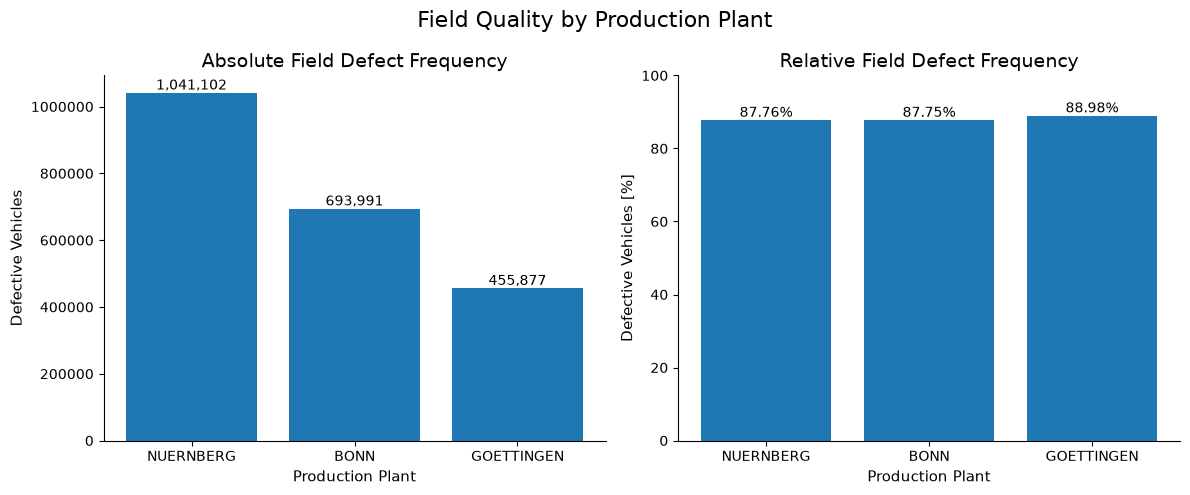

In [16]:
plant_order = [
    "NUERNBERG",
    "BONN",
    "GOETTINGEN"
]

plot_data = (
    plant_kpi
    .set_index("ORT_OEM")
    .loc[plant_order]
    .reset_index()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

bars_absolute = axes[0].bar(
    plot_data["ORT_OEM"],
    plot_data["Defective_Vehicles"]
)

axes[0].set_title(
    "Absolute Field Defect Frequency"
)

axes[0].set_xlabel(
    "Production Plant"
)

axes[0].set_ylabel(
    "Defective Vehicles"
)

axes[0].set_ylim(
    bottom=0
)

axes[0].ticklabel_format(
    style="plain",
    axis="y"
)

for bar, value in zip(
    bars_absolute,
    plot_data["Defective_Vehicles"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

bars_relative = axes[1].bar(
    plot_data["ORT_OEM"],
    plot_data["Defect_Rate_%"]
)

axes[1].set_title(
    "Relative Field Defect Frequency"
)

axes[1].set_xlabel(
    "Production Plant"
)

axes[1].set_ylabel(
    "Defective Vehicles [%]"
)

axes[1].set_ylim(
    0,
    100
)

for bar, value in zip(
    bars_relative,
    plot_data["Defect_Rate_%"]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

fig.suptitle(
    "Field Quality by Production Plant",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [8]:
highest_absolute = plant_kpi.loc[
    plant_kpi["Defective_Vehicles"].idxmax()
]

highest_relative = plant_kpi.loc[
    plant_kpi["Defect_Rate_%"].idxmax()
]

second_relative = (
    plant_kpi
    .sort_values(
        "Defect_Rate_%",
        ascending=False
    )
    .iloc[1]
)

relative_gap = (
    highest_relative["Defect_Rate_%"]
    - second_relative["Defect_Rate_%"]
)

decision_snapshot = pd.DataFrame(
    {
        "Indicator": [
            "Highest absolute defect burden",
            "Highest relative defect frequency",
            "Relative gap to next plant"
        ],
        "Result": [
            f"{highest_absolute['Plant']} — {highest_absolute['Defective_Vehicles']:,.0f} defective vehicles",
            f"{highest_relative['Plant']} — {highest_relative['Defect_Rate_%']:.2f}%",
            f"{relative_gap:.2f} percentage points"
        ]
    }
)

display(decision_snapshot)


,Indicator,Result
0,Highest absolute defect burden,"Nürnberg — 1,041,102 defective vehicles"
1,Highest relative defect frequency,Göttingen — 88.98%
2,Relative gap to next plant,1.22 percentage points


## Initial Audit Candidate

The required KPIs point in different directions:

- **Nürnberg** has the largest absolute number of defective vehicles.
- **Göttingen** has the highest relative field defect frequency despite the smallest production volume of the three plants.

The relative KPI therefore makes Göttingen the **initial audit candidate**. The following diagnostics test whether this difference is actually associated with the production process or with the structure of the supplied components and parts.


# KPI 2 — Component-Level Defect Prevalence

A component is considered defective if the component itself or any individual part installed in it is defective.

These rates do **not** add up to the vehicle defect rate because multiple defective components can occur in the same vehicle.


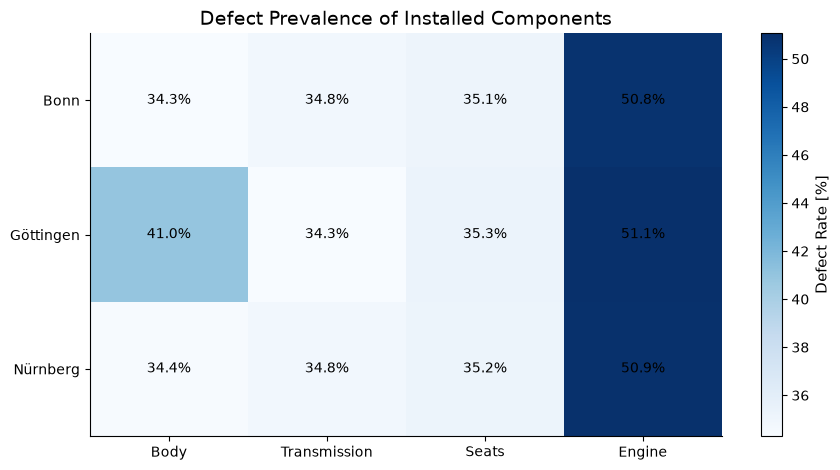

In [9]:
component_columns = {
    "Body": "Fehlerhaft_Karosserie",
    "Transmission": "Fehlerhaft_Schaltung",
    "Seats": "Fehlerhaft_Sitze",
    "Engine": "Fehlerhaft_Motor"
}

component_rows = []

for component, column in component_columns.items():
    summary = (
        vehicle_quality
        .groupby(
            "ORT_OEM",
            as_index=False
        )
        .agg(
            Defect_Rate=(
                column,
                "mean"
            )
        )
    )

    summary["Component"] = component

    component_rows.append(
        summary
    )

component_kpi = pd.concat(
    component_rows,
    ignore_index=True
)

component_kpi["Plant"] = (
    component_kpi["ORT_OEM"]
    .map(plant_names)
    .fillna(component_kpi["ORT_OEM"])
)

component_kpi["Defect_Rate_%"] = (
    component_kpi["Defect_Rate"]
    * 100
)

component_matrix = (
    component_kpi
    .pivot(
        index="Plant",
        columns="Component",
        values="Defect_Rate_%"
    )
    .reindex(
        columns=[
            "Body",
            "Transmission",
            "Seats",
            "Engine"
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(9, 4.8)
)

image = ax.imshow(
    component_matrix,
    cmap="Blues",
    aspect="auto"
)

ax.set_xticks(
    range(
        len(component_matrix.columns)
    ),
    labels=component_matrix.columns
)

ax.set_yticks(
    range(
        len(component_matrix.index)
    ),
    labels=component_matrix.index
)

for i in range(
    len(component_matrix.index)
):
    for j in range(
        len(component_matrix.columns)
    ):
        value = component_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center"
        )

ax.set_title(
    "Defect Prevalence of Installed Components"
)

fig.colorbar(
    image,
    ax=ax,
    label="Defect Rate [%]"
)

plt.tight_layout()
plt.show()


### What stands out?

The engine has the highest defect prevalence at all plants, but this is largely common across the network.

The more distinctive difference is the **body defect rate in Göttingen**, which is substantially higher than in Nürnberg and Bonn. The next diagnostic checks whether that difference originates in the body component itself or in the individual parts contained in it.


# KPI 3 — Body Defects: Component Itself vs. Included Parts


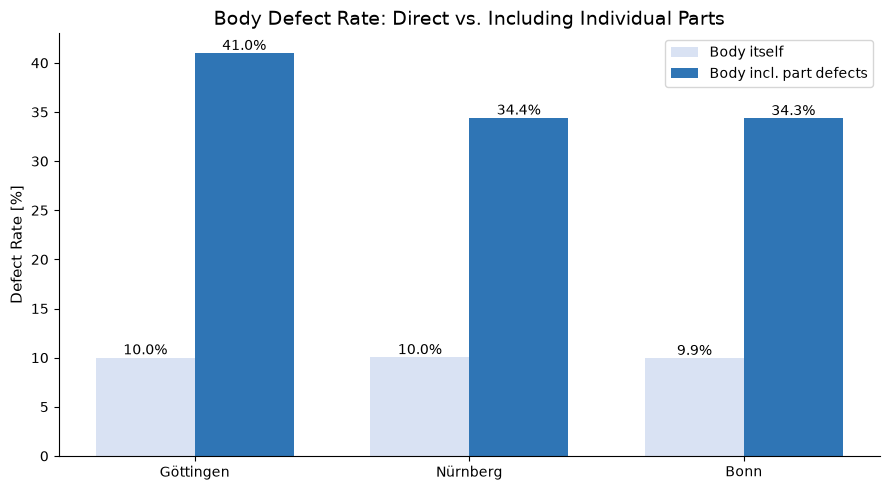

In [10]:
body_kpi = (
    vehicle_quality
    .groupby(
        "ORT_OEM",
        as_index=False
    )
    .agg(
        Direct_Body_Defect_Rate=(
            "Fehlerhaft_Karosserie_Roh",
            "mean"
        ),
        Total_Body_Defect_Rate=(
            "Fehlerhaft_Karosserie",
            "mean"
        )
    )
)

body_kpi["Plant"] = (
    body_kpi["ORT_OEM"]
    .map(plant_names)
    .fillna(body_kpi["ORT_OEM"])
)

body_kpi["Direct_Body_Defect_Rate_%"] = (
    body_kpi["Direct_Body_Defect_Rate"]
    * 100
)

body_kpi["Total_Body_Defect_Rate_%"] = (
    body_kpi["Total_Body_Defect_Rate"]
    * 100
)

body_kpi = body_kpi.sort_values(
    "Total_Body_Defect_Rate_%",
    ascending=False
)

x = np.arange(
    len(body_kpi)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(9, 5)
)

bars_direct = ax.bar(
    x - width / 2,
    body_kpi["Direct_Body_Defect_Rate_%"],
    width,
    label="Body itself",
    color=MUTED
)

bars_total = ax.bar(
    x + width / 2,
    body_kpi["Total_Body_Defect_Rate_%"],
    width,
    label="Body incl. part defects",
    color=ACCENT
)

ax.set_xticks(
    x,
    labels=body_kpi["Plant"]
)

ax.set_ylabel(
    "Defect Rate [%]"
)

ax.set_title(
    "Body Defect Rate: Direct vs. Including Individual Parts"
)

ax.legend()

for bars in [
    bars_direct,
    bars_total
]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()


The direct body defect rate is approximately the same across the three production plants. Göttingen's higher total body defect rate therefore does not originate from the body component itself; it appears after individual-part defects are propagated into the body.


# KPI 4 — Architecture-Adjusted Defect Burden

Type11 and Type21 do not contain the same number of inspected objects. Because the final vehicle status is an OR-condition across the vehicle, components, and individual parts, a vehicle with more underlying objects has more opportunities to be classified as defective.

The diagnostic below therefore compares the field defect rate with the number of direct defect events per inspected object.


In [11]:
normalized_kpi = (
    vehicle_quality
    .groupby(
        [
            "ORT_OEM",
            "Fahrzeugtyp"
        ],
        as_index=False
    )
    .agg(
        Vehicles=(
            "ID_Fahrzeug",
            "size"
        ),
        Defective_Vehicles=(
            "Fehlerhaft_Gesamt",
            "sum"
        ),
        Direct_Defect_Events=(
            "Anzahl_Direkte_Fehler",
            "sum"
        ),
        Inspected_Objects=(
            "Anzahl_Pruefobjekte",
            "sum"
        ),
        Objects_Per_Vehicle=(
            "Anzahl_Pruefobjekte",
            "mean"
        )
    )
)

normalized_kpi["Plant"] = (
    normalized_kpi["ORT_OEM"]
    .map(plant_names)
    .fillna(normalized_kpi["ORT_OEM"])
)

normalized_kpi["Field_Defect_Rate_%"] = (
    normalized_kpi["Defective_Vehicles"]
    / normalized_kpi["Vehicles"]
    * 100
)

normalized_kpi["Direct_Defects_Per_Object_%"] = (
    normalized_kpi["Direct_Defect_Events"]
    / normalized_kpi["Inspected_Objects"]
    * 100
)

display(
    normalized_kpi[
        [
            "Plant",
            "Fahrzeugtyp",
            "Vehicles",
            "Objects_Per_Vehicle",
            "Field_Defect_Rate_%",
            "Direct_Defects_Per_Object_%"
        ]
    ]
    .sort_values(
        "Direct_Defects_Per_Object_%",
        ascending=False
    )
    .style.format(
        {
            "Vehicles": "{:,.0f}",
            "Objects_Per_Vehicle": "{:.0f}",
            "Field_Defect_Rate_%": "{:.2f}%",
            "Direct_Defects_Per_Object_%": "{:.2f}%"
        }
    )
)


,Plant,Fahrzeugtyp,Vehicles,Objects_Per_Vehicle,Field_Defect_Rate_%,Direct_Defects_Per_Object_%
2,Nürnberg,Type11,"1,186,298",18,87.76%,10.97%
0,Bonn,Type11,"790,866",18,87.75%,10.96%
1,Göttingen,Type21,"512,354",19,88.98%,10.89%


This diagnostic changes the interpretation of the original field-defect ranking. Göttingen's higher vehicle-level defect rate occurs together with a larger number of inspected objects per vehicle, while its direct defect-event rate per inspected object is not the highest.

This suggests that the higher relative field defect rate in Göttingen is at least partly a **vehicle-architecture / BOM effect**, rather than clear evidence of a worse OEM production process.


# KPI 5 — Tier-1 Supplier Direct Defect Rates

The final vehicle dataset also retains the Tier-1 plant responsible for each installed component. This allows direct component defects to be compared by supplier plant without reopening the raw component files.


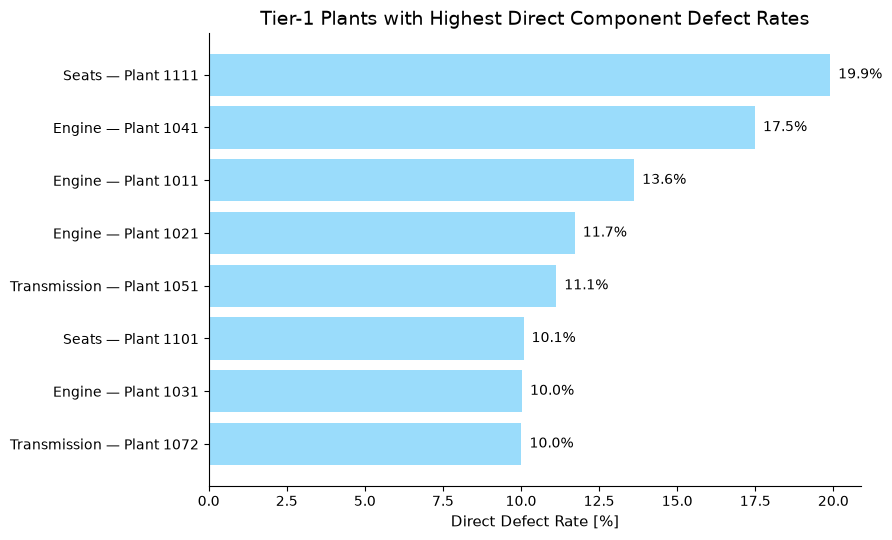

In [13]:
supplier_specs = {
    "Body": (
        "Tier1_Werksnummer_Karosserie",
        "Fehlerhaft_Karosserie_Roh"
    ),
    "Transmission": (
        "Tier1_Werksnummer_Schaltung",
        "Fehlerhaft_Schaltung_Roh"
    ),
    "Seats": (
        "Tier1_Werksnummer_Sitze",
        "Fehlerhaft_Sitze_Roh"
    ),
    "Engine": (
        "Tier1_Werksnummer_Motor",
        "Fehlerhaft_Motor_Roh"
    )
}

supplier_rows = []

for component, (
    plant_column,
    defect_column
) in supplier_specs.items():
    summary = (
        vehicle_quality
        .groupby(
            plant_column,
            as_index=False
        )
        .agg(
            Installed_Units=(
                defect_column,
                "size"
            ),
            Direct_Defects=(
                defect_column,
                "sum"
            )
        )
        .rename(
            columns={
                plant_column: "Tier1_Plant"
            }
        )
    )

    summary["Component"] = component

    summary["Direct_Defect_Rate_%"] = (
        summary["Direct_Defects"]
        / summary["Installed_Units"]
        * 100
    )

    supplier_rows.append(
        summary
    )

tier1_kpi = pd.concat(
    supplier_rows,
    ignore_index=True
)

tier1_kpi["Label"] = (
    tier1_kpi["Component"]
    + " — Plant "
    + tier1_kpi["Tier1_Plant"].astype(str)
)

tier1_top = (
    tier1_kpi[
        tier1_kpi["Installed_Units"] >= 50_000
    ]
    .nlargest(
        8,
        "Direct_Defect_Rate_%"
    )
    .sort_values(
        "Direct_Defect_Rate_%",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

bars = ax.barh(
    tier1_top["Label"],
    tier1_top["Direct_Defect_Rate_%"],
    color=MAIN
)

ax.set_title(
    "Tier-1 Plants with Highest Direct Component Defect Rates"
)

ax.set_xlabel(
    "Direct Defect Rate [%]"
)

for bar, value in zip(
    bars,
    tier1_top["Direct_Defect_Rate_%"]
):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()


# KPI 6 — Field Geography

Registration data provide a field-location perspective. The map below shows municipality-level vehicle defect rates for municipalities with enough registrations to avoid highlighting very small samples.


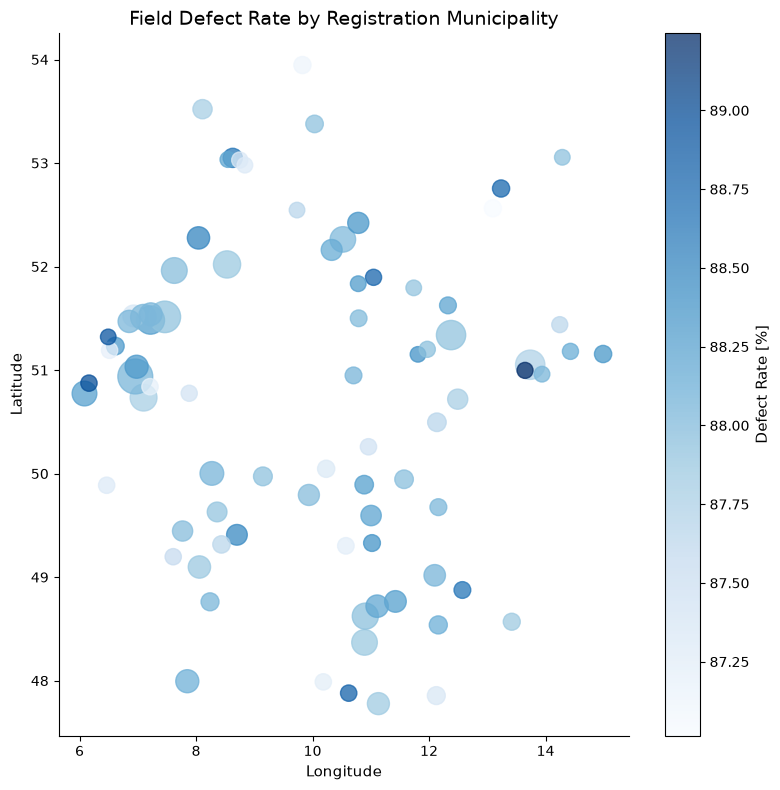

In [14]:
municipality_kpi = (
    vehicle_quality
    .dropna(
        subset=[
            "Breitengrad_Gemeinde",
            "Laengengrad_Gemeinde"
        ]
    )
    .groupby(
        [
            "Gemeinde_Zulassung",
            "Breitengrad_Gemeinde",
            "Laengengrad_Gemeinde"
        ],
        as_index=False
    )
    .agg(
        Vehicles=(
            "ID_Fahrzeug",
            "size"
        ),
        Defective_Vehicles=(
            "Fehlerhaft_Gesamt",
            "sum"
        )
    )
)

municipality_kpi["Defect_Rate_%"] = (
    municipality_kpi["Defective_Vehicles"]
    / municipality_kpi["Vehicles"]
    * 100
)

minimum_volume = max(
    1000,
    int(
        len(vehicle_quality)
        * 0.001
    )
)

municipality_map = municipality_kpi[
    municipality_kpi["Vehicles"] >= minimum_volume
].copy()

fig, ax = plt.subplots(
    figsize=(8, 8)
)

points = ax.scatter(
    municipality_map["Laengengrad_Gemeinde"],
    municipality_map["Breitengrad_Gemeinde"],
    c=municipality_map["Defect_Rate_%"],
    s=np.sqrt(
        municipality_map["Vehicles"]
    ) * 2.5,
    cmap="Blues",
    alpha=0.75
)

ax.set_title(
    "Field Defect Rate by Registration Municipality"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

fig.colorbar(
    points,
    ax=ax,
    label="Defect Rate [%]"
)

plt.tight_layout()
plt.show()


# Audit Recommendation

The required field KPIs initially identify Göttingen because it has the highest relative defect frequency. The deeper diagnostics, however, show that Göttingen's excess is strongly associated with propagated body-part defects and a larger number of inspected objects in Type21.

Nürnberg combines the **largest absolute field-quality burden** with the **highest direct defect-event rate per inspected object** after accounting for vehicle structure.

**Recommended next process audit: Nürnberg.**

Göttingen should still be monitored, but its higher raw relative field defect rate should not be interpreted as direct evidence of a worse OEM assembly process.
